In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio as rio
from rasterio.mask import mask
from rasterio.warp import reproject, Resampling, calculate_default_transform
from rasterio.io import MemoryFile
from shapely import Polygon, Point
from os import cpu_count
from concurrent.futures import ThreadPoolExecutor
from threading import Lock
import pickle
from sklearn.preprocessing import RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from src.mslandcover.config import MSTM_PROJ4, LEGEND_CLASSES, LEGEND_COLORS_HEX

plt.rcParams['font.family'] = 'Times New Roman'

In [2]:
# load boundary file for Mississippi
ms_gdf = gpd.read_file('./data/sampling/cb_2023_28_bg_500k')

# create grid over Mississippi
ms_gdf = ms_gdf.to_crs(MSTM_PROJ4)
ms_polygon = ms_gdf.dissolve().geometry[0]

x_min, y_min, x_max, y_max = ms_polygon.bounds
x_delta, y_delta = 256, 256

grid_gdf = gpd.GeoDataFrame(
    geometry=[Polygon([
        (x, y), 
        (x+x_delta, y),
        (x+x_delta, y+y_delta),
        (x, y+y_delta),
    ]) for x in np.arange(x_min, x_max, x_delta) for y in np.arange(y_min, y_max, y_delta)], 
    crs=MSTM_PROJ4,
)

# keep only the grid cells that intersect the state
grid_gdf = grid_gdf.loc[grid_gdf.intersects(ms_polygon)]
grid_gdf.to_parquet('./data/sampling/grid_MSTM.par') # NOTE: this file is in MSTM projection
print(f'Total number of candidate patches: {len(grid_gdf)}')

Total number of candidate patches: 1889606


In [3]:
# clip NLCD data to grid
# could use state boundary, but some cells slightly protrude outside of the state
# better to use grid boundary

with rio.open('./data/sampling/NLCD/Annual_NLCD_LndCov_2023_CU_C1V0.tif') as src:
    
    full_grid = grid_gdf.to_crs(src.crs).dissolve().geometry
    
    out_image, out_transform = mask(src, full_grid, crop=True, all_touched=True)
    out_meta = src.meta.copy()
    out_meta.update({
        'height': out_image.shape[1],
        'width': out_image.shape[2],
        'transform': out_transform,
    })
    
    # save masked data
    with rio.open(f'./data/sampling/NLCD/NLCD_MS.tif', 'w', **out_meta) as dst:
        dst.write(out_image)

In [4]:
# reproject raster to MSTM projection
with rio.open('./data/sampling/NLCD/NLCD_MS.tif') as src:
    
    dest_transform, dest_width, dest_height = calculate_default_transform(
        src.crs, 
        MSTM_PROJ4, 
        src.width, 
        src.height, 
        *src.bounds
    )
    
    out_meta = src.meta.copy()
    out_meta.update({
        'crs': MSTM_PROJ4,
        'transform': dest_transform,
        'width': dest_width,
        'height': dest_height,
    })
    
    with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM.tif', 'w', **out_meta) as dst:
        
        reproject(
            source=rio.band(src, 1),
            destination=rio.band(dst, 1),
            src_transform=src.transform,
            src_crs=src.crs, 
            dst_transform=dest_transform,
            dst_crs=MSTM_PROJ4, 
            resampling=Resampling.nearest,
        )

In [5]:
# Reclassify from NLCD Level II to our land cover classes
# 0: Nodata (250)
# 1: Water (11)
# 2: Impervious surfaces (21, 22)
# 3: Raised structures (23, 24)
# 4: Barren (31)
# 5: Forest (41, 42, 43)
# 6: Herbaceous (52, 71, 81, 95)
# 7: Cultivated Crops (82)
# 8: Unclassified (N/A)

reclassification_dict = {
    11: 1, # open water -> water
    21: 2, # developed, open space -> impervious surfaces
    22: 2, # developed, low intensity -> impervious surfaces
    23: 3, # developed, medium intensity -> raised structures
    24: 3, # developed, high intensity -> raised structures
    31: 4, # barren land -> barren
    41: 5, # deciduous forest -> forest
    42: 5, # evergreen forest -> forest
    43: 5, # mixed forest -> forest
    90: 5, # woody wetlands -> forest
    52: 6, # shrub/scrub -> herbaceous
    71: 6, # grassland/herbaceous -> herbaceous
    81: 6, # pasture/hay -> herbaceous
    95: 6, # emergent herbaceous wetlands -> herbaceous
    82: 7, # cultivated crops -> cultivated crops
    250: 0, # nodata -> nodata
}

with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM.tif') as src:
    data = src.read(1)
    meta = src.meta

reclassified_data = np.vectorize(reclassification_dict.get)(data)

# update metadata
meta.update({
    'dtype': rio.uint8,
    'count': 1,
    'nodata': 0,
    'compress': 'lz77',
})

with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif', 'w', **meta) as dst:
    dst.write(reclassified_data, 1)

In [10]:
# now for the fun part: extract zonal histograms from each grid cell
def extract_zonal_histogram(geom, src, lock):
    with lock:
        out_image, _ = mask(src, [geom], crop=True, all_touched=False, nodata=0)
    return dict(zip(*np.unique(out_image[0], return_counts=True)))

lock = Lock()
n_cpus = cpu_count()
with MemoryFile(open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif', 'rb')) as memfile:
    with rio.open(memfile) as src:
        with ThreadPoolExecutor(4 * n_cpus) as executor:
            grid_counts = executor.map(
                lambda geom: extract_zonal_histogram(geom, src, lock),
                grid_gdf.geometry,
            )

# save grid counts
grid_counts = list(grid_counts)
with open('./data/sampling/grid_counts.pkl', 'wb') as f:
    pickle.dump(grid_counts, f)

In [14]:
# transform list of dicts with counts to list of vectors corresponding to histograms 
# that are all of the same dimensionality based on the unique values in the raster

# get unique values in data
unique_values = np.unique(np.concatenate([list(gc.keys()) for gc in grid_counts]))
values_map = {v: i for i, v in enumerate(unique_values)}

print(unique_values, values_map)

# create vectors of histograms
histograms = np.zeros((len(grid_counts), len(unique_values) - 1), dtype=int) # -1 to exclude nodata value
for i, grid_count in enumerate(grid_counts):
    for k, v in grid_count.items():
        # do not inlude nodata values (0)
        if k == 0:
            continue
        histograms[i, values_map[k-1]] = v # -1 to account for missing nodata value

# normalize histograms (each vector sums to 1)
histograms = histograms / histograms.sum(axis=1, keepdims=True)
np.save('./data/sampling/histogram_vectors.npy', histograms)

[0 1 2 3 4 5 6 7] {np.uint8(0): 0, np.uint8(1): 1, np.uint8(2): 2, np.uint8(3): 3, np.uint8(4): 4, np.uint8(5): 5, np.uint8(6): 6, np.uint8(7): 7}


In [15]:
# time to perform PCA and cluster
n_components = 2
n_clusters = 250
random_state = 1701

scaler = RobustScaler() # robust to outliers
pca = PCA(n_components=n_components, random_state=random_state)
kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)

hist_scaled = scaler.fit_transform(histograms)
hist_pca = pca.fit_transform(hist_scaled)

grid_gdf['hist_vector'] = [v for v in histograms]
grid_gdf['hist_vector_scaled'] = [v for v in hist_scaled]
grid_gdf['hist_vector_pca'] = [v for v in hist_pca]

print(f'Percent of variance explained by {n_components} principal components: {100*pca.explained_variance_ratio_.sum():.2f}%')
for i in range(pca.n_components_):
    print(f'PC{i+1} explains {100*pca.explained_variance_ratio_[i]:.2f}% of variance')

clusters = kmeans.fit_predict(hist_pca)
grid_gdf['cluster'] = clusters
print(f'Number of clusters: {n_clusters}')
print(f'Minimum number of samples in a cluster: {np.unique(clusters, return_counts=True)[1].min()}')

grid_gdf.to_parquet(f'./data/sampling/grid_MSTM_{n_clusters}_clusters.par')

Percent of variance explained by 2 principal components: 94.24%
PC1 explains 76.51% of variance
PC2 explains 17.74% of variance
Number of clusters: 250
Minimum number of samples in a cluster: 410


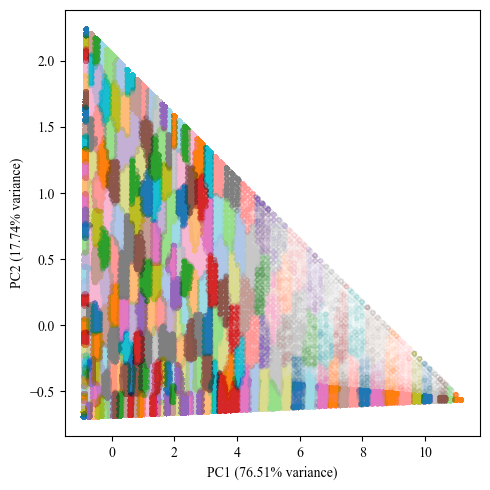

In [17]:
# plot clusters in PC space
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(hist_pca[:, 0], hist_pca[:, 1], c=clusters, cmap='tab20', s=10, alpha=0.01)
ax.set_xlabel(f'PC1 ({100*pca.explained_variance_ratio_[0]:.2f}% variance)')
ax.set_ylabel(f'PC2 ({100*pca.explained_variance_ratio_[1]:.2f}% variance)')
fig.tight_layout()
plt.savefig(f'./paper/images/sampling/clusters_{n_clusters}.png', dpi=300)
plt.show()

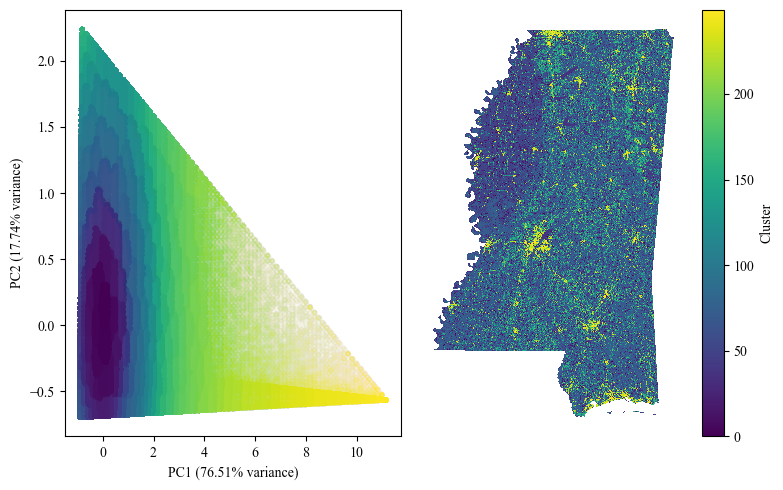

In [18]:
# visualize clusters on map
grids_copy = grid_gdf.copy()

# order the clusters such that they can be colored in a way that clusters with
# similar values have similar colors

# get cluster centers
cluster_centers = pca.inverse_transform(kmeans.cluster_centers_)
# cluster_centers = scaler.inverse_transform(cluster_centers)

# get the order of the clusters based on the cluster centers
cluster_order = np.argsort(np.sum(np.square(kmeans.cluster_centers_), axis=1))

# map the cluster order to the original cluster labels
cluster_map = {cluster: i for i, cluster in enumerate(cluster_order)}
grids_copy['cluster'] = grids_copy['cluster'].map(cluster_map)

# plot clusters using PCs
fig, ax = plt.subplots(1, 2, figsize=(8, 5))

scatter = ax[0].scatter(hist_pca[:, 0], hist_pca[:, 1], c=grids_copy['cluster'], cmap='viridis', s=10, alpha=0.01)
ax[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)')
ax[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)')

grids_copy.plot(column='cluster', ax=ax[1], legend=True, cmap='viridis', legend_kwds={'label': 'Cluster'})
ax[1].axis('off')

fig.tight_layout()
plt.savefig('./paper/images/sampling/clusters_map.png', dpi=300)

In [19]:
# sample pathces for training, testing, and validation sets - for each cluster, sample 4 patches
grid_gdf = gpd.read_parquet(f'./data/sampling/grid_MSTM_250_clusters.par')
random_state = 1701

n_train_samples_per_cluster = 2
n_val_samples_per_cluster = 1
n_test_samples_per_cluster = 1
n_pretraining_samples = int(0.2 * len(grid_gdf)) # sample 20% of total patches for pretraining
n_pretraining_val_samples = int(0.05 * len(grid_gdf)) # sample 5% of total patches for pretraining validation set

train_patches_gdf = grid_gdf.groupby('cluster').sample(n=n_train_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = grid_gdf[~grid_gdf.index.isin(train_patches_gdf.index)]

val_patches_gdf = remaining_candidate_patches_gdf.groupby('cluster').sample(n=n_val_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(val_patches_gdf.index)]

test_patches_gdf = remaining_candidate_patches_gdf.groupby('cluster').sample(n=n_test_samples_per_cluster, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(test_patches_gdf.index)]

# sample pretraining last to enforce disjoint splits
pretraining_patches_gdf = remaining_candidate_patches_gdf.sample(n=n_pretraining_samples, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(pretraining_patches_gdf.index)]

pretraining_val_patches_gdf = remaining_candidate_patches_gdf.sample(n=n_pretraining_val_samples, random_state=random_state)
remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~remaining_candidate_patches_gdf.index.isin(pretraining_val_patches_gdf.index)]

print(f'Number of pretraining samples: {len(pretraining_patches_gdf)}')
print(f'Number of pretraining validation samples: {len(pretraining_val_patches_gdf)}')
print(f'Number of training samples: {len(train_patches_gdf)}')
print(f'Number of validation samples: {len(val_patches_gdf)}')
print(f'Number of testing samples: {len(test_patches_gdf)}')

for df, name in zip(
    [train_patches_gdf, val_patches_gdf, test_patches_gdf, pretraining_patches_gdf, pretraining_val_patches_gdf], 
    ['train', 'val', 'test', 'pretrain', 'pretrain_val']
):
    df['split'] = name

samples_gdf = pd.concat([pretraining_patches_gdf, pretraining_val_patches_gdf, train_patches_gdf, val_patches_gdf, test_patches_gdf])
samples_gdf.to_parquet('./data/sampling/samples.par')
remaining_candidate_patches_gdf.to_parquet('./data/sampling/remaining_candidate_patches.par')

Number of pretraining samples: 377921
Number of pretraining validation samples: 94480
Number of training samples: 500
Number of validation samples: 250
Number of testing samples: 250


In [8]:
import rasterio as rio
import matplotlib.pyplot as plt
import numpy as np
from src.mslandcover.config import LEGEND_CLASSES, LEGEND_COLORS_HEX
import geopandas as gpd

plt.rcParams['font.family'] = 'Times New Roman'

samples_gdf = gpd.read_parquet('./data/sampling/samples.par')

0.07172771759266873 0.00759940110706302 0.07172771759266873


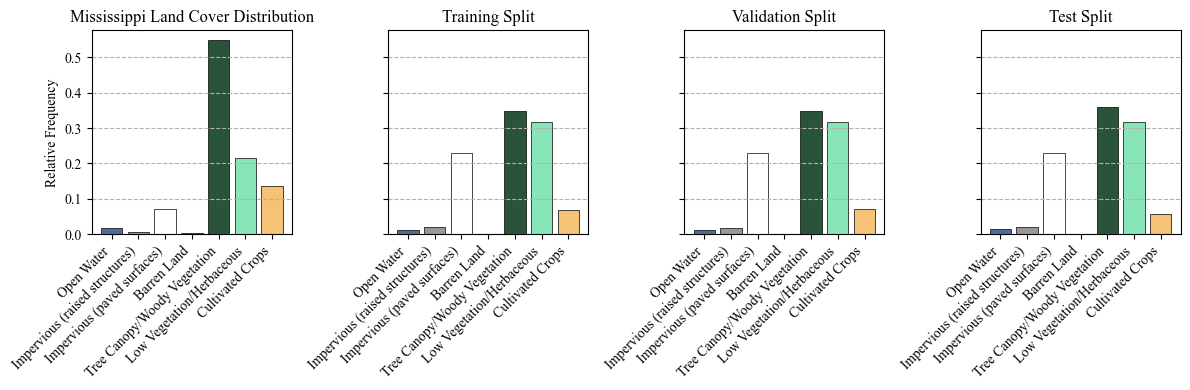

In [ ]:
# examine distributions of land cover classes in each split with respect to the full dataset
with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif') as src:
    full_dist = dict(zip(*np.unique(src.read(1), return_counts=True)))

# remove nodata from full distribution
full_dist.pop(0)

# normalize full distribution
full_dist = {k: v / sum(full_dist.values()) for k, v in full_dist.items()}

# NOTE: I got impervious surfaces and raised structures mixed up in the original reclassification mapping
# reclassify impervious surfaces to 3 and raised structures to 2
temp = full_dist[2]
full_dist[2] = full_dist[3]
full_dist[3] = temp

fig, ax = plt.subplots(1, 4, figsize=(12, 4), sharey=True)

# plot full distribution
ax[0].bar(full_dist.keys(), full_dist.values(), color=[LEGEND_COLORS_HEX[k] for k in full_dist.keys()], edgecolor='black', linewidth=0.5)
ax[0].set_title('Mississippi Land Cover Distribution')
ax[0].set_ylabel('Relative Frequency')
ax[0].set_xticks(list(full_dist.keys()))
ax[0].set_xticklabels([LEGEND_CLASSES[k] for k in full_dist.keys()], rotation=45, ha='right')
ax[0].grid(axis='y', linestyle='--')


# plot distribution of each split
split_titles = ['Training', 'Validation', 'Test']
split_names = ['train', 'val', 'test']

for i, split_name in enumerate(split_names):
    
    split_hist = np.array(list(samples_gdf[samples_gdf['split'] == split_name]['hist_vector']))
    split_hist = split_hist / split_hist.sum(axis=1, keepdims=True)
    
    split_hist = split_hist.mean(axis=0)
    split_dist = dict(zip(range(1, 9), split_hist))
    
    split_dist_temp = split_dist[2]
    split_dist[2] = split_dist[3]
    split_dist[3] = split_dist_temp
    
    ax[i+1].bar(split_dist.keys(), split_dist.values(), color=[LEGEND_COLORS_HEX[k] for k in split_dist.keys()], edgecolor='black', linewidth=0.5)
    ax[i+1].set_title(f'{split_titles[i]} Split')
    ax[i+1].set_xticks(list(split_dist.keys()))
    ax[i+1].set_xticklabels([LEGEND_CLASSES[k] for k in split_dist.keys()], rotation=45, ha='right')
    ax[i+1].grid(axis='y', linestyle='--')

fig.tight_layout()
plt.savefig('./paper/images/sampling/split_distributions.png', dpi=300)

In [24]:
# save centroids of train, val, and test patches for visualization later
tvt_gdf = samples_gdf.loc[samples_gdf['split'].isin(['train', 'val', 'test'])].copy()
tvt_gdf['geometry'] = tvt_gdf['geometry'].map(lambda x: x.centroid)
tvt_gdf[['split', 'cluster', 'geometry']].to_file('./data/sampling/tvt_centroids.gpkg', driver='GPKG')

In [25]:
# Ideally, we want to minimize the number of patches that are entirely of one class
def mono_class(hist_vector):
    return sum(hist_vector == 1.0) == 1

full_grid_percent_single_class = 100 * len(grid_gdf[grid_gdf['hist_vector'].apply(mono_class)]) / len(grid_gdf)
samples_percent_single_class = 100 * len(tvt_gdf[tvt_gdf['hist_vector'].apply(mono_class)]) / len(tvt_gdf)

print(f'Percentage of patches that are entirely of one class in full grid: {full_grid_percent_single_class:.2f}%')
print(f'Percentage of patches that are entirely of one class in samples: {samples_percent_single_class:.2f}%')

Percentage of patches that are entirely of one class in full grid: 29.96%
Percentage of patches that are entirely of one class in samples: 1.90%


In [ ]:
# criteria for selecting points for accuracy assessment
# 1. points are stratified according to reclassified NLCD data (with occoruences of each class proportional to the square root of the class probability)
# 3. points are within the state boundary
# 4. points are note within the same grid cell as a sample patch (pretraining, train, val, or test)
# 5. no more than 1 point per grid cell

with rio.open('./data/sampling/NLCD/NLCD_MS_MSTM_reclassified.tif') as src:
    data = src.read(1)
    
    # georeferencing functions
    row_col_to_xy = src.xy
    xy_to_row_col = src.index

# get distirbution of NLCD Level I classes
_, class_counts = np.unique(data, return_counts=True)
class_probs = class_counts / class_counts.sum()
# first class is nodoata, so remove it
class_probs = class_probs[1:] ** 0.5 # square root to increase the number of points for classes with lower probabilities

min_class = class_probs.min()

n_points_per_class = np.round(200 * class_probs / min_class).astype(int)
print(n_points_per_class, n_points_per_class.sum())

def sample_points(class_index, points_to_sample, data, ms_polygon, remaining_candidate_patches_gdf):
    
    running_class_points = 0
    sample_points = []
    while running_class_points < points_to_sample:
        
        row = np.random.randint(0, data.shape[0])
        col = np.random.randint(0, data.shape[1])
        
        # check to make sure point is of the correct class
        if data[row, col] != class_index:
            continue
        
        # transform row, col to x, y
        x, y = row_col_to_xy(row, col)
        point = Point(x, y)
        
        # check if point is within state boundary
        if not ms_polygon.contains(point):
            continue
        
        # check if point is in an eligible grid cell
        intersecting_grid_cell = remaining_candidate_patches_gdf.intersects(point)
        if intersecting_grid_cell.any():
            continue
        
        # remove grid cell that intersects point
        remaining_candidate_patches_gdf = remaining_candidate_patches_gdf.drop(remaining_candidate_patches_gdf[intersecting_grid_cell].index)
        # remaining_candidate_patches_gdf = remaining_candidate_patches_gdf[~intersecting_grid_cell]
        
        sample_points.append({
            'class': class_index,
            'geometry': point,
        })
        
        running_class_points += 1
        
        if running_class_points % 10 == 0:
            print(f'Class {class_index}: {running_class_points}/{points_to_sample} points sampled', end='\r')

    print(f'Class {class_index}: {running_class_points} points sampled')
    return sample_points

for i, n in enumerate(n_points_per_class):
    sample_points_futures = sample_points(i+1, n, data, ms_polygon, remaining_candidate_patches_gdf)

sample_points = list(sample_points_futures)
with open('./data/sampling/sample_points.pkl', 'wb') as f:
    pickle.dump(sample_points, f)